# 02 — Unsupervised Anomaly Detection

Baselines: Isolation Forest and Local Outlier Factor.
No fraud labels used during training.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
from src.data.generator import generate_transactions, get_train_test_split
from src.data.preprocessor import preprocess
from src.models.isolation_forest import train_isolation_forest, anomaly_scores_if, train_lof, anomaly_scores_lof
from src.evaluation.metrics import evaluate, ks_statistic, plot_pr_curves, plot_score_distributions
plt.rcParams['figure.dpi'] = 120

df = generate_transactions(n=20_000, fraud_rate=0.02, seed=42)
X_train, X_test, y_train, y_test = get_train_test_split(df, seed=42)
X_train_s, X_test_s, pipe = preprocess(X_train, X_test)
y_true = y_test.values
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Test fraud: {y_true.mean():.2%}")

Train: 16,000 | Test: 4,000 | Test fraud: 2.00%


In [2]:
print("Training Isolation Forest (n_estimators=200)...")
if_model = train_isolation_forest(X_train_s, contamination=0.02, n_estimators=200)
if_scores = anomaly_scores_if(if_model, X_test_s)

print("Training LOF (n_neighbors=20)...")
lof_model = train_lof(X_train_s, contamination=0.02, n_neighbors=20)
lof_scores = anomaly_scores_lof(lof_model, X_test_s)

metrics_if  = evaluate(y_true, if_scores,  threshold=0.50, model_name='Isolation Forest')
metrics_lof = evaluate(y_true, lof_scores, threshold=0.50, model_name='LOF')

print("\n=== Unsupervised Model Comparison ===")
for m in [metrics_if, metrics_lof]:
    ks = ks_statistic(y_true, if_scores if m['model']=='Isolation Forest' else lof_scores)
    print(f"  {m['model']:20s}  AUC-PR={m['avg_precision']:.3f}  AUC-ROC={m['roc_auc']:.3f}  KS={ks:.3f}")

Training Isolation Forest (n_estimators=200)...


Training LOF (n_neighbors=20)...



=== Unsupervised Model Comparison ===
  Isolation Forest      AUC-PR=0.739  AUC-ROC=0.982  KS=0.906
  LOF                   AUC-PR=0.077  AUC-ROC=0.566  KS=0.226


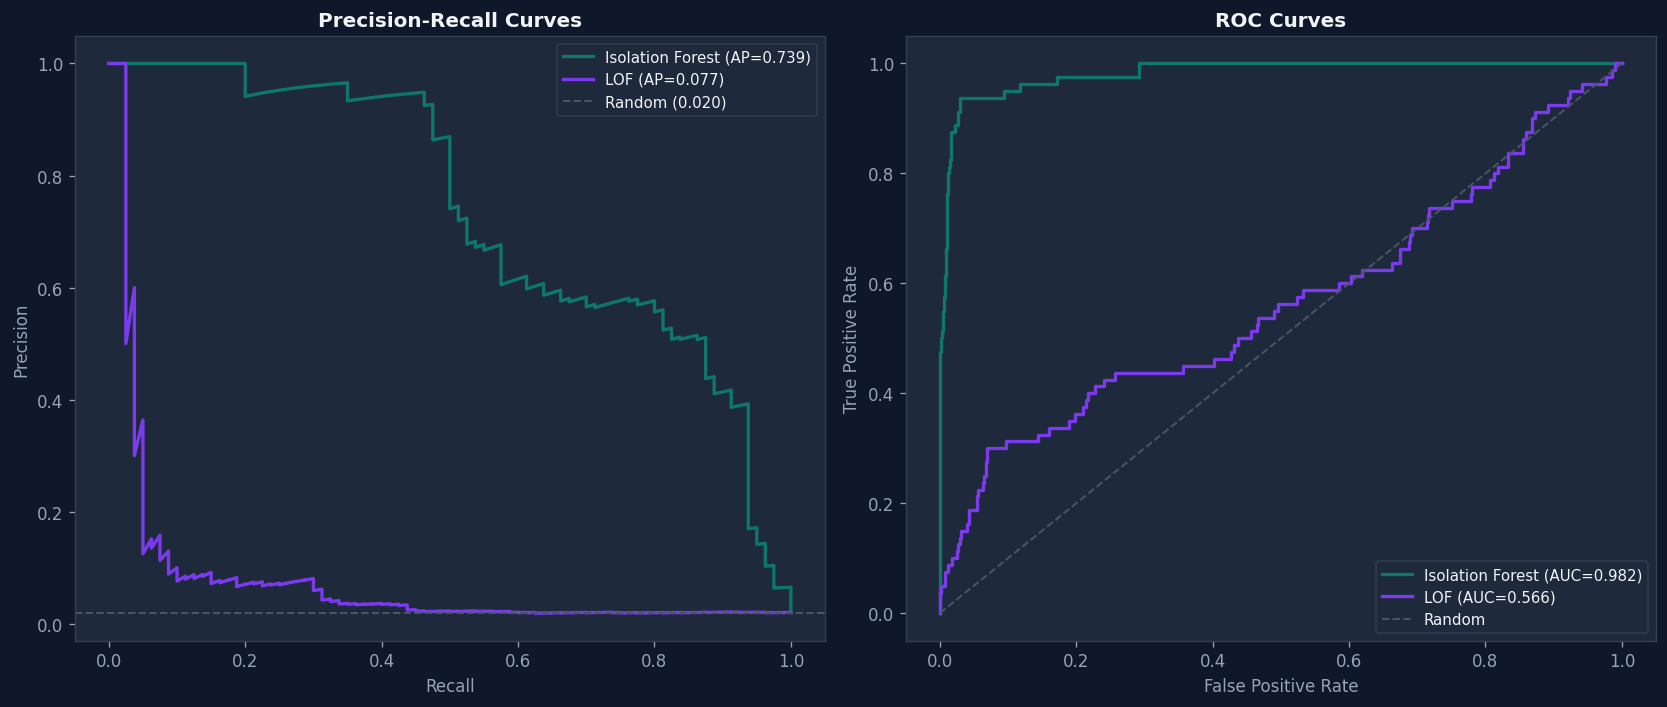

In [3]:
score_dict = {'Isolation Forest': if_scores, 'LOF': lof_scores}
plot_pr_curves([], y_true, score_dict, save_path='../outputs/figures/02_pr_roc_curves.png')

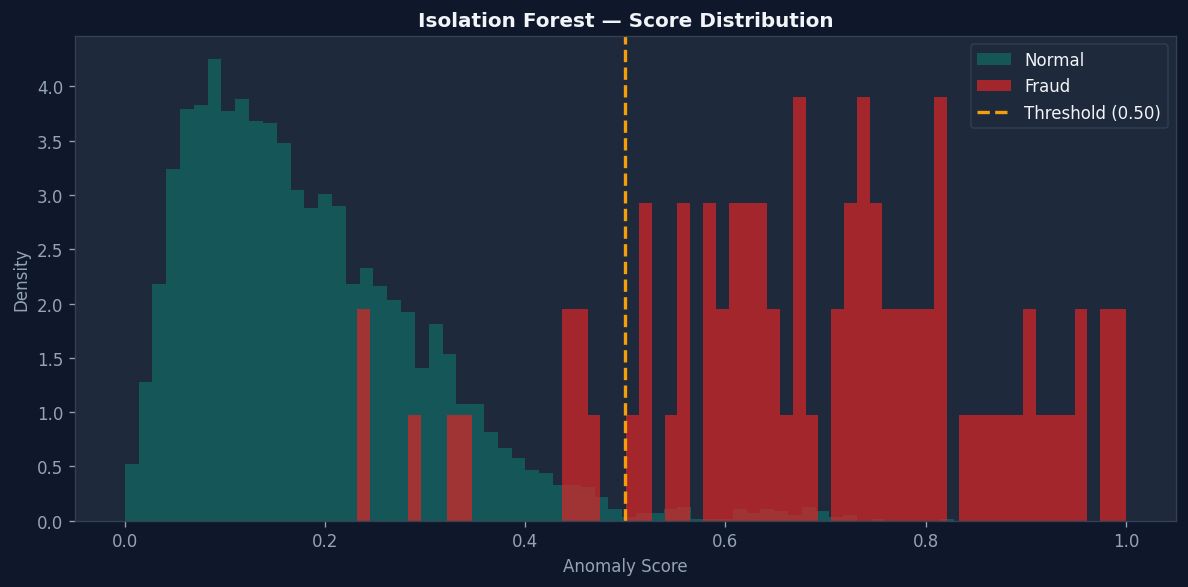

In [4]:
plot_score_distributions(y_true, if_scores, model_name='Isolation Forest',
                         threshold=0.50, save_path='../outputs/figures/02_if_score_dist.png')

## Feature Importance via Permutation

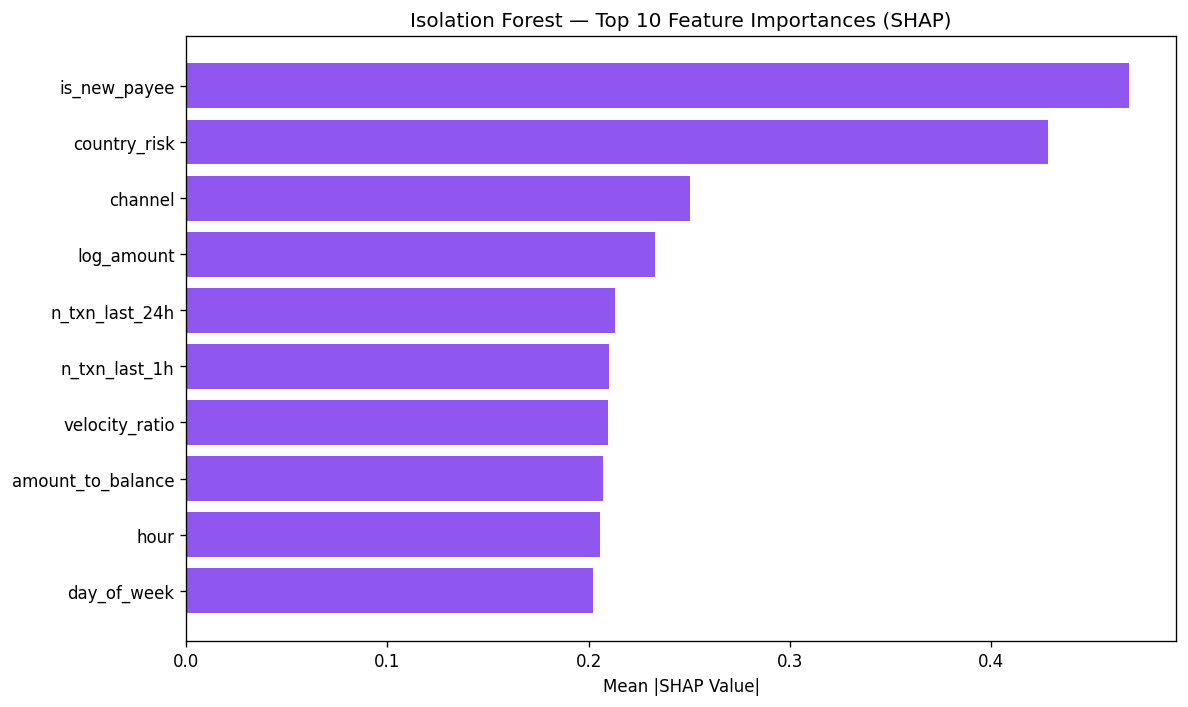

In [5]:
import shap
explainer = shap.TreeExplainer(if_model)
shap_values = explainer.shap_values(X_test_s[:500])
from src.data.generator import FEATURE_COLS
fig, ax = plt.subplots(figsize=(10, 6))
mean_abs_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]
ax.barh([FEATURE_COLS[i] for i in sorted_idx[:10]][::-1],
        mean_abs_shap[sorted_idx[:10]][::-1], color='#7c3aed', alpha=0.85)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Isolation Forest — Top 10 Feature Importances (SHAP)')
plt.tight_layout()
plt.savefig('../outputs/figures/02_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()